#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

#### 2) Loading Data:

In [2]:
df = pd.read_csv('Universities.csv')

In [3]:
df.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90


In [4]:
df.shape

(25, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Univ      25 non-null     object
 1   SAT       25 non-null     int64 
 2   Top10     25 non-null     int64 
 3   Accept    25 non-null     int64 
 4   SFRatio   25 non-null     int64 
 5   Expenses  25 non-null     int64 
 6   GradRate  25 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.5+ KB


In [6]:
df.describe()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
count,25.000000,25.000000,25.000000,25.00000,25.000000,25.000000
mean,1266.440000,76.480000,39.200000,12.72000,27388.000000,86.720000
std,108.359771,19.433905,19.727308,4.06735,14424.883165,9.057778
min,1005.000000,28.000000,14.000000,6.00000,8704.000000,67.000000
25%,1240.000000,74.000000,24.000000,11.00000,15140.000000,81.000000
50%,1285.000000,81.000000,36.000000,12.00000,27553.000000,90.000000
75%,1340.000000,90.000000,50.000000,14.00000,34870.000000,94.000000
max,1415.000000,100.000000,90.000000,25.00000,63575.000000,97.000000


- Data has all numerical features except University Name (Univ).
- University name is not needed for clustering as it will help the algorithm seperate data unfairly.

In [7]:
# Dropping University Name from data:
df.drop('Univ', axis= 1, inplace= True)

In [8]:
df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,1310,89,22,13,22704,94
1,1415,100,25,6,63575,81
2,1260,62,59,9,25026,72
3,1310,76,24,12,31510,88
4,1280,83,33,13,21864,90


#### 3) Data Exploration and Transformation:

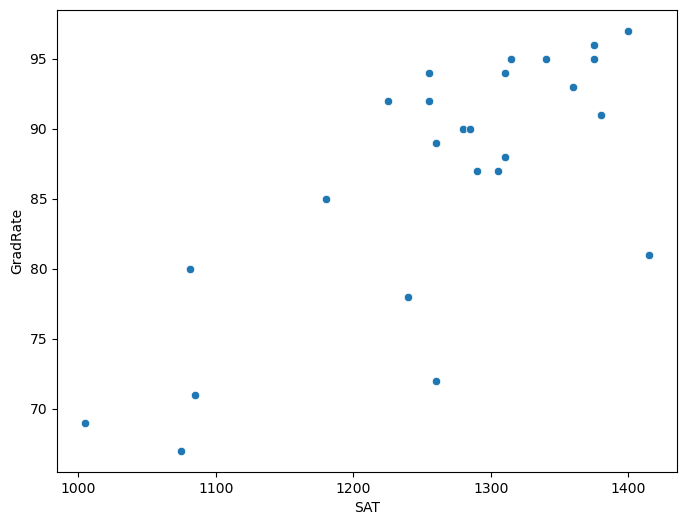

In [10]:
# SAT vs GradRate:

plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "SAT", y= "GradRate")
plt.show()

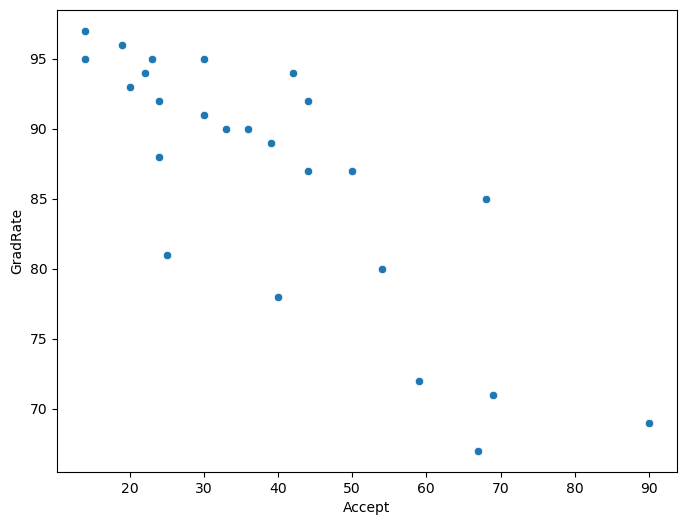

In [11]:
# Accept vs GradRate:

plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "Accept", y= "GradRate")
plt.show()

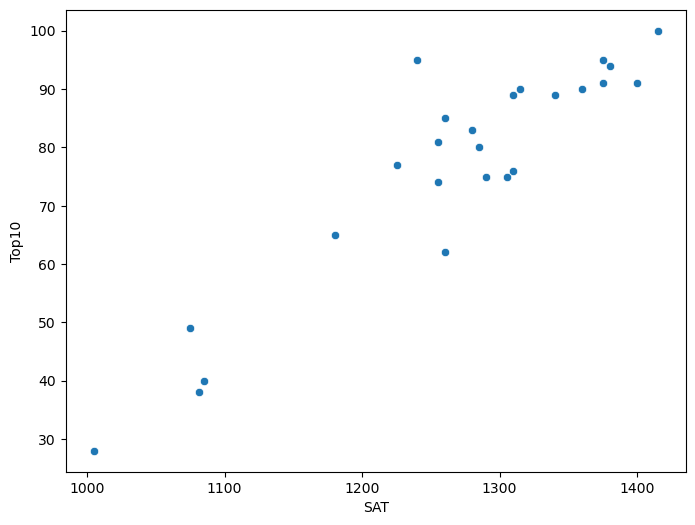

In [12]:
# SAT vs Top10:

plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "SAT", y= "Top10")
plt.show()

As all the features are Numeric and Continuous, we will apply scaling to all of them.

In [13]:
sc = StandardScaler()
X = sc.fit_transform(df)
X

array([[ 0.41028362,  0.6575195 , -0.88986682,  0.07026045, -0.33141256,
         0.82030265],
       [ 1.39925928,  1.23521235, -0.73465749, -1.68625071,  2.56038138,
        -0.64452351],
       [-0.06065717, -0.76045386,  1.02438157, -0.93346022, -0.16712136,
        -1.65863393],
       [ 0.41028362, -0.02520842, -0.78639393, -0.18066972,  0.29164871,
         0.14422904],
       [ 0.12771914,  0.34241431, -0.32076595,  0.07026045, -0.39084607,
         0.36958691],
       [ 0.69284809,  0.6575195 , -0.83813038, -0.68253005,  0.33778044,
         0.93298158],
       [ 0.4573777 ,  0.71003703, -0.47597528, -0.18066972,  0.29695528,
         0.93298158],
       [-0.10775125, -0.13024348, -0.78639393, -0.18066972, -0.51381683,
         0.59494478],
       [ 1.25797704,  0.76255456, -1.30375836, -0.43159988,  0.85874344,
         1.15833946],
       [ 0.36318954, -0.07772595,  0.24833493, -1.43532055,  2.21481798,
         0.0315501 ],
       [ 1.06960072,  0.92010716, -0.47597528, -0.

#### 4) Finding Optimal Number of Clusters:

In [15]:
# Looping through different number of clusters to find Optimal Value:

sil_score = []

for k in range(2, 11):
    agc = AgglomerativeClustering(n_clusters= k, linkage= 'average') #Agglomerative Cluster Instance
    clusters = agc.fit_predict(X) #Fittng Agglomerative clustering on data
    sil_score.append(silhouette_score(X= X, labels= clusters))

In [16]:
sil_score

[0.5503694030201671,
 0.4004412524998169,
 0.3663483568606949,
 0.33972291864915966,
 0.3133593999000424,
 0.2769977091020079,
 0.2784595723780759,
 0.2440608239688779,
 0.2445781435755417]

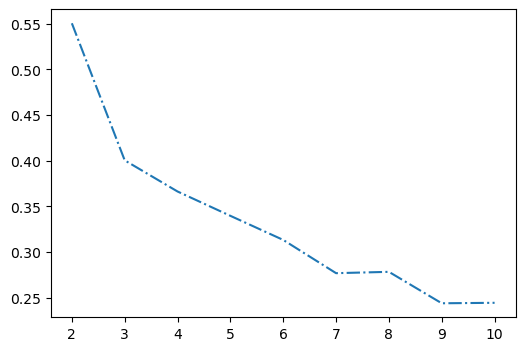

In [18]:
# Visualizing Silhouetter Score:

plt.figure(figsize= (6,4))
sns.lineplot(x= range(2, 11), y= sil_score, ls= '-.')
plt.show()

- 2 Seems to be Optimal Number of Clusters according to Silhouette Score.

#### 5) Clustering:

In [23]:
agc = AgglomerativeClustering(n_clusters= 2, linkage= 'average')
clusters = agc.fit_predict(X)

In [24]:
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0])

Attaching Cluster Numbers as a Column to the Original Dataframe

In [25]:
df['Cluster'] = clusters

In [26]:
df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Cluster
0,1310,89,22,13,22704,94,0
1,1415,100,25,6,63575,81,0
2,1260,62,59,9,25026,72,0
3,1310,76,24,12,31510,88,0
4,1280,83,33,13,21864,90,0


Visualizing Cluster seperation with different features:

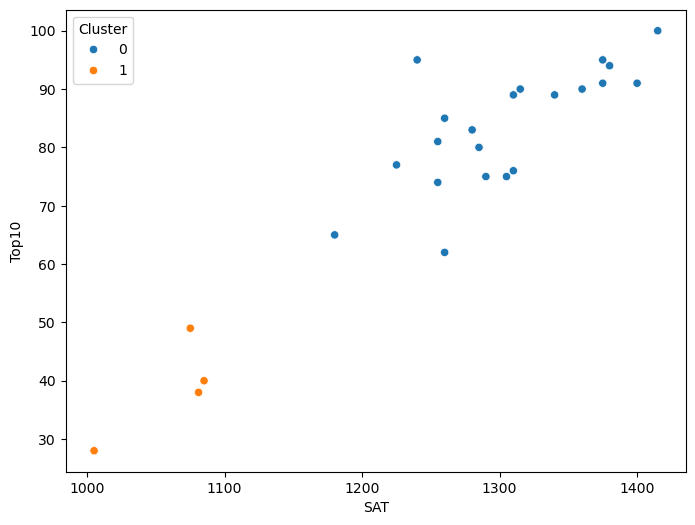

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "SAT", y= "Top10", hue= "Cluster")
plt.show()

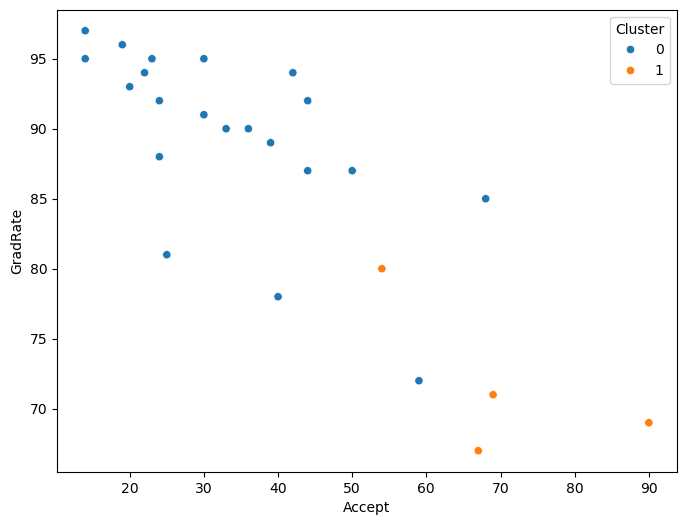

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "Accept", y= "GradRate", hue= "Cluster")
plt.show()

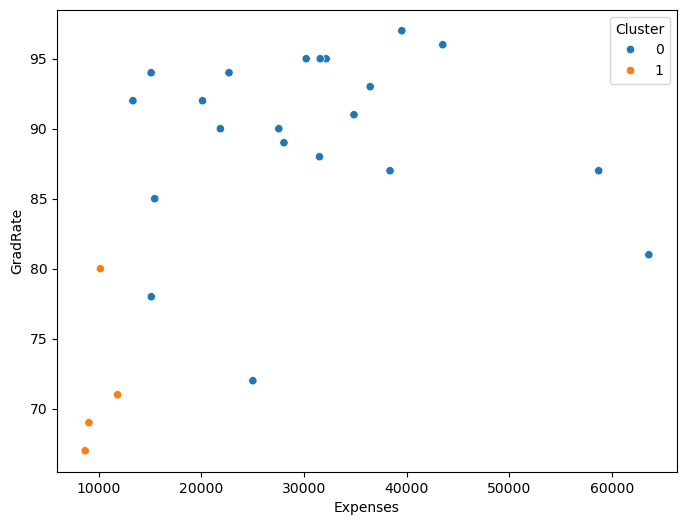

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "Expenses", y= "GradRate", hue= "Cluster")
plt.show()

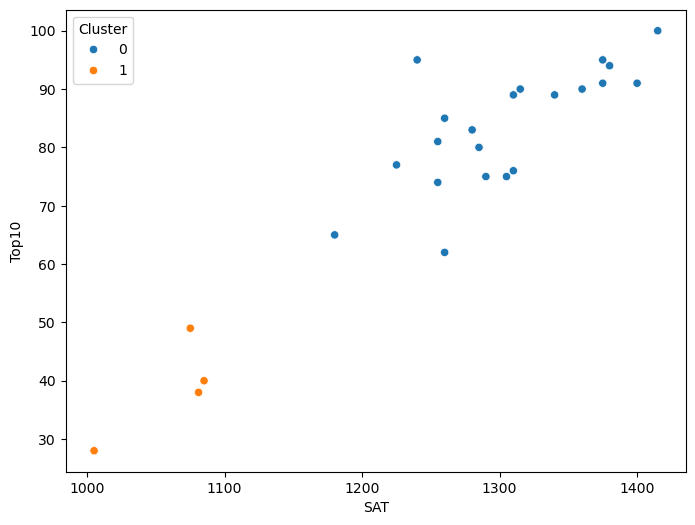

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "SAT", y= "Top10", hue= "Cluster")
plt.show()

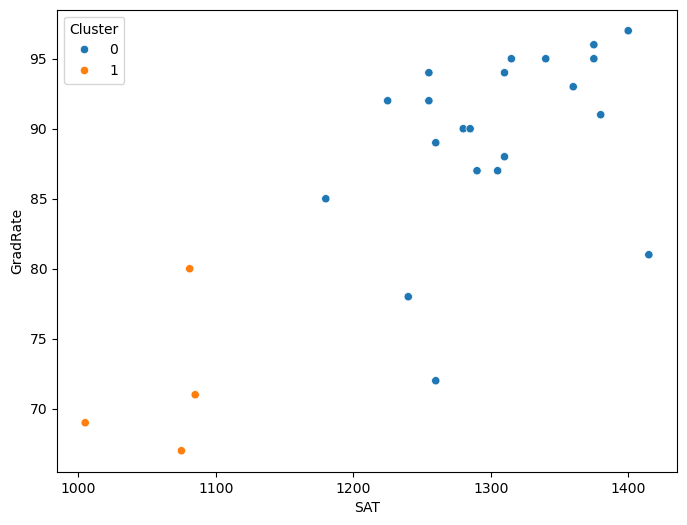

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x= "SAT", y= "GradRate", hue= "Cluster")
plt.show()

As can be seen from the charts above, we are geting preety good cluster separation for data points.

#### 6) Dendrogram:

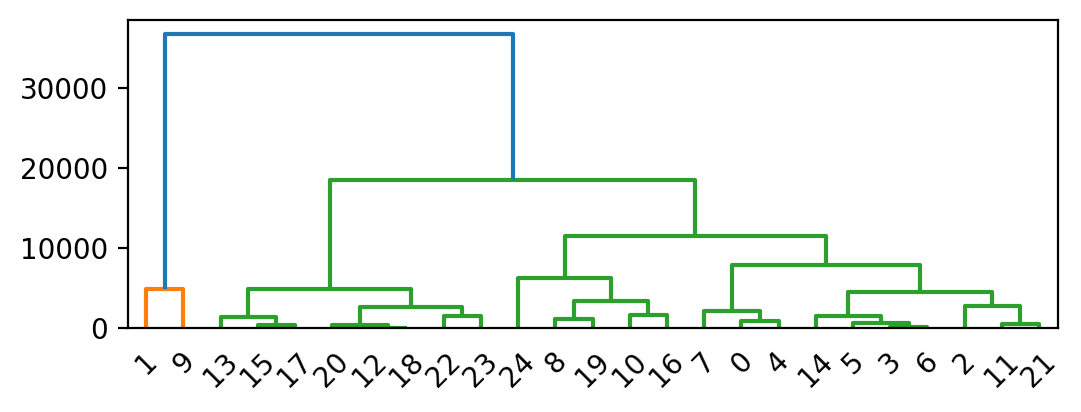

In [37]:
plt.figure(figsize= (6, 2), dpi= 200)
dendrogram = sch.dendrogram(sch.linkage(df.drop('Cluster', axis= 1), method= 'average'))
plt.show()